# Baseline Model

This notebook establishes a baseline model for the tree crown detection task. The goal of the baseline is not to achieve the best possible performance, but to create a simple and reproducible reference point against which later models can be compared.

For this baseline, we use DeepForest, a pretrained tree crown detection model. The model is applied zero-shot to the Denmark test dataset, meaning that it is not trained or fine-tuned on the target dataset. This makes the baseline useful as a lower-bound reference: any later domain-specific model should improve upon this result.

The baseline uses only RGB information because DeepForest expects standard RGB image input. Although the dataset also contains additional channels such as infrared, NDVI, and CHM, these are intentionally excluded from the baseline. This allows us to later evaluate whether using richer spectral and height information improves performance.


## Table of Contents

1. Model Choice
2. Feature Selection
3. Data Loading
4. RGB Preprocessing
5. DeepForest Prediction
6. Prediction and Annotation Conversion
7. Evaluation
8. Result Saving and Visualization
9. Baseline Interpretation


## Library setup

The baseline notebook uses standard Python libraries for numerical computation, file handling, image loading, and geometric processing. DeepForest is used as the pretrained baseline model. The ground-truth annotations are stored as polygon coordinates, so Shapely is used to convert those polygons into geometric objects for later evaluation.

The main libraries used are:

* `numpy` and `pandas` for numerical processing and tabular results
* `PIL` for loading image bands
* `DeepForest` for zero-shot tree crown detection
* `Shapely` for polygon-to-circle conversion
* `matplotlib` for qualitative visualization


## Step 1: Environment setup

This baseline notebook uses DeepForest as a pretrained tree crown detection model. DeepForest and its supporting libraries are installed at the beginning of the notebook to make the workflow reproducible in a clean environment such as Google Colab.

The installation step upgrades `pip` and installs the packages required for the baseline workflow:

- `deepforest` for pretrained tree crown detection
- `shapely` for geometric operations on tree crown polygons
- `pandas` and `numpy` for tabular and numerical processing
- `pillow` for image loading
- `matplotlib` for visualization

This setup is specific to the baseline model. The baseline is not trained from scratch; it uses a pretrained DeepForest model directly on the test data.

# Step 1: Install packages for the DeepForest baseline notebook

In [30]:
import sys

!{sys.executable} -m pip install -q --upgrade pip
!{sys.executable} -m pip install -q deepforest shapely pandas pillow matplotlib

## Step 2: Import libraries and initialize the baseline model

In this step, we import the libraries required for the baseline workflow and initialize the pretrained DeepForest model.

DeepForest is used as the baseline because it provides an already trained tree crown detector. This makes it suitable for a zero-shot baseline: the model is applied directly to the Denmark test images without any additional training or fine-tuning.

The imported libraries support the following tasks:

- `math` and `numpy` are used for numerical calculations, including circle radius and IoU computation.
- `json` is used to load the ground-truth annotation files.
- `pandas` is used to store and summarize evaluation results.
- `Path` is used for clean file and folder handling.
- `PIL.Image` is used to load the red, green, and blue image bands.
- `DeepForest` provides the pretrained tree detection model.
- `Shapely` is used to convert tree crown polygon annotations into geometric objects.
- `matplotlib` is used for visual inspection and qualitative result visualization.

The final check confirms that all imports work and that the DeepForest model object can be created successfully.

# Step 2: Import necessary libraries and initialize DeepForest

In [31]:
import math
import json
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from deepforest import main
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

print("All imports successful.")

# Check DeepForest model object can be created
model = main.deepforest()
print("DeepForest model object created.")

All imports successful.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


DeepForest model object created.


## Step 3: Download the Denmark test dataset

The baseline model is evaluated on the Denmark test dataset. The dataset is downloaded from the ERDA public data repository and contains normalized image patches together with tree crown annotations.

For this baseline, only the red, green, and blue bands are used because DeepForest accepts RGB images as input. However, the dataset also contains additional channels such as infrared, NDVI, and CHM, which can be used later by more advanced models.

The downloaded file is stored in `/content/Data` so that the notebook has a clear and reproducible data directory.

# Step 3: Download Denmark test data from ERDA

In [32]:

import requests
from pathlib import Path

url = "https://sid.erda.dk/share_redirect/eFt21tspNe/denmark/extracted_data_test_patch_normalized.zip"

data_dir = Path("/content/Data")
data_dir.mkdir(exist_ok=True)

zip_path = data_dir / "extracted_data_test_patch_normalized.zip"

if not zip_path.exists():
    print("Downloading:", url)
    response = requests.get(url, stream=True)
    response.raise_for_status()

    total = 0
    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                total += len(chunk)
                print(f"Downloaded {total / (1024*1024):.1f} MB", end="\r")

    print("\nDownload complete:", zip_path)
else:
    print("Zip already exists:", zip_path)

print("File size MB:", zip_path.stat().st_size / (1024 * 1024))

Zip already exists: /content/Data/extracted_data_test_patch_normalized.zip
File size MB: 54.99440097808838


## Step 4: Extract and inspect the test dataset

After downloading the dataset, the zip archive is extracted and the contents are inspected. This step verifies that the expected test folder is present and that the required files are available.

The DeepForest baseline requires the red, green, and blue image bands for each test tile, together with the corresponding annotation JSON file. The dataset also contains additional files such as NDVI, infrared, CHM, annotation masks, and count maps, but these are not used in the RGB-only baseline.

This inspection step is important because it prevents silent path errors before running model inference.

# Step 4: Extract and inspect Denmark test data

In [33]:
import zipfile
from pathlib import Path

zip_path = Path("/content/Data/extracted_data_test_patch_normalized.zip")
extract_dir = Path("/content/Data/extracted_data_test_patch_normalized")

# Extract
if not extract_dir.exists():
    print("Extracting zip file...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print("Extracted folder already exists.")

print("Extracted to:", extract_dir)

# Show top-level contents
print("\nTop-level contents:")
for item in sorted(extract_dir.iterdir()):
    if item.is_dir():
        print("[DIR] ", item.name)
    else:
        print("[FILE]", item.name)

# Count relevant file types
print("\nFile counts:")
for pattern in ["*.png", "*.json", "*.tif", "*.tiff", "*.npy", "*.csv"]:
    files = list(extract_dir.rglob(pattern))
    print(f"{pattern}: {len(files)}")
    for f in files[:10]:
        print("  -", f.relative_to(extract_dir))

Extracted folder already exists.
Extracted to: /content/Data/extracted_data_test_patch_normalized

Top-level contents:
[DIR]  extracted_data_2aux_test_v4_centroids_all_classes_final

File counts:
*.png: 200
  - extracted_data_2aux_test_v4_centroids_all_classes_final/green_24.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/red_4.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/ann_kernel_20.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/ndvi_8.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/red_16.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/green_21.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/red_6.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/green_22.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/chm_9.png
  - extracted_data_2aux_test_v4_centroids_all_classes_final/ann_kernel_12.png
*.json: 25
  - extracted_data_2aux_test_v4_centroids_all_classes_f

## Step 5: Define and validate the test directory

In this step, we define the path to the extracted Denmark test dataset and verify that each test tile contains the files required for the DeepForest baseline.

For each tile, the baseline requires:

- `red_*.png`
- `green_*.png`
- `blue_*.png`
- `annotation_*.json`

The red, green, and blue bands are used to construct the RGB input image for DeepForest. The annotation JSON file contains the ground-truth tree crown polygons used for evaluation.

This validation step ensures that all expected files are present before running model inference.

# Step 5: Set test directory and verify expected file groups

In [34]:
from pathlib import Path

DATA_ROOT = Path("/content/Data/extracted_data_test_patch_normalized")
TEST_DIR = DATA_ROOT / "extracted_data_2aux_test_v4_centroids_all_classes_final"

print("TEST_DIR:", TEST_DIR)
print("TEST_DIR exists:", TEST_DIR.exists())

# Find available image indices from red_*.png
indices = sorted([
    int(p.stem.split("_")[1])
    for p in TEST_DIR.glob("red_*.png")
])

print("Number of test tiles:", len(indices))
print("Indices:", indices)

# Check that each index has the required RGB files and annotation file
missing = []

for idx in indices:
    required_files = [
        TEST_DIR / f"red_{idx}.png",
        TEST_DIR / f"green_{idx}.png",
        TEST_DIR / f"blue_{idx}.png",
        TEST_DIR / f"annotation_{idx}.json",
    ]

    for f in required_files:
        if not f.exists():
            missing.append(f.name)

print("Missing required files:", missing)

# Show available channels for first index
if indices:
    first_idx = indices[0]
    print("\nFiles for first tile index:", first_idx)
    for f in sorted(TEST_DIR.glob(f"*_{first_idx}.*")):
        print("-", f.name)

TEST_DIR: /content/Data/extracted_data_test_patch_normalized/extracted_data_2aux_test_v4_centroids_all_classes_final
TEST_DIR exists: True
Number of test tiles: 25
Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Missing required files: []

Files for first tile index: 0
- ann_kernel_0.png
- annotation_0.json
- annotation_0.png
- blue_0.png
- chm_0.png
- count_0.npy
- green_0.png
- infrared_0.png
- ndvi_0.png
- red_0.png


## Step 6: Inspect one test tile and its annotation

Before running the baseline model, we inspect one test tile to understand the input data format and the annotation structure.

The dataset stores each spectral band as a separate image file. For the DeepForest baseline, the red, green, and blue bands are stacked to form an RGB image. The annotation file contains tree crown polygons under the `Trees` key.

This inspection step is important because it revealed that the image bands are stored as normalized floating-point values rather than standard `uint8` RGB images. Therefore, an additional preprocessing step is required before passing the image to DeepForest.

# Step 6: Inspect one RGB tile and annotation structure

Red shape: (1226, 757) float32 -2.914183 2.682608
Green shape: (1226, 757) float32 -3.1306474 3.3757107
Blue shape: (1226, 757) float32 -3.4095223 3.52315
RGB shape: (1226, 757, 3) float32 -3.4095223 3.52315

Annotation keys: dict_keys(['Trees'])
Number of tree polygons: 37
First tree polygon example:
[[197, 606], [195, 613], [195, 613], [195, 615], [201, 624], [204, 627], [207, 629], [209, 630], [211, 630], [214, 630], [216, 630], [216, 630], [218, 629], [221, 629], [223, 628], [223, 628], [225, 627], [227, 625], [228, 625], [232, 623], [233, 622], [236, 621], [238, 618], [238, 615], [237, 611], [236, 609], [234, 605], [232, 601], [231, 601], [229, 601], [226, 600], [223, 600], [217, 600], [215, 600], [213, 601], [208, 601], [205, 602], [203, 603], [200, 604], [198, 604], [197, 606]]


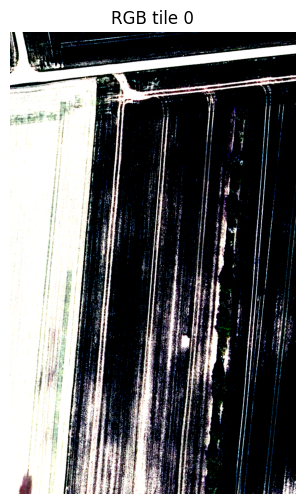

In [35]:
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

idx = 0

# Load RGB bands
red = np.array(Image.open(TEST_DIR / f"red_{idx}.png"))
green = np.array(Image.open(TEST_DIR / f"green_{idx}.png"))
blue = np.array(Image.open(TEST_DIR / f"blue_{idx}.png"))

rgb = np.stack([red, green, blue], axis=-1)

print("Red shape:", red.shape, red.dtype, red.min(), red.max())
print("Green shape:", green.shape, green.dtype, green.min(), green.max())
print("Blue shape:", blue.shape, blue.dtype, blue.min(), blue.max())
print("RGB shape:", rgb.shape, rgb.dtype, rgb.min(), rgb.max())

# Load annotation
ann_path = TEST_DIR / f"annotation_{idx}.json"

with open(ann_path, "r") as f:
    ann = json.load(f)

print("\nAnnotation keys:", ann.keys())

if "Trees" in ann:
    print("Number of tree polygons:", len(ann["Trees"]))
    if len(ann["Trees"]) > 0:
        print("First tree polygon example:")
        print(ann["Trees"][0])
else:
    print("No 'Trees' key found.")

# Show RGB image
plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"RGB tile {idx}")
plt.axis("off")
plt.show()

## Step 7: Preprocess RGB bands for DeepForest

The Denmark image bands are stored as normalized floating-point arrays rather than standard RGB images. The inspected RGB tile had values outside the usual display range, approximately from `-3.4` to `+3.5`. This is why `matplotlib` clipped the image during visualization.

DeepForest expects a standard RGB image input, typically with three channels and pixel values in the range `0–255`. Therefore, the red, green, and blue bands are converted into an 8-bit RGB image before prediction.

The conversion uses percentile-based normalization for each band:

1. The 2nd and 98th percentiles are used to reduce the influence of extreme values.
2. Values are clipped to this percentile range.
3. The clipped values are rescaled to `0–255`.
4. The result is converted to `uint8`.

This preprocessing is specific to the RGB-only DeepForest baseline. The additional channels available in the dataset, such as infrared, NDVI, and CHM, are intentionally excluded from this baseline.

# Step 7: Helper function to load normalized RGB bands for DeepForest

RGB uint8 shape: (1226, 757, 3)
RGB uint8 dtype: uint8
RGB uint8 min: 0
RGB uint8 max: 254


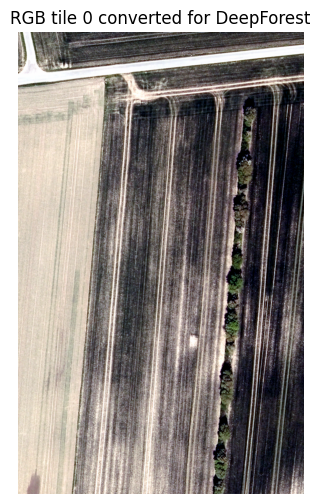

In [36]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def normalize_to_uint8(arr):
    """
    Convert a normalized float array to uint8 range [0, 255].
    Uses percentile clipping to reduce the effect of extreme values.
    """
    arr = arr.astype(np.float32)

    p2, p98 = np.percentile(arr, (2, 98))
    arr = np.clip(arr, p2, p98)

    arr = (arr - p2) / (p98 - p2 + 1e-6)
    arr = (arr * 255).astype(np.uint8)

    return arr


def load_rgb_for_deepforest(test_dir, idx):
    """
    Load red, green, blue normalized PNG bands and convert them
    into a uint8 RGB image suitable for DeepForest.
    """
    red = np.array(Image.open(test_dir / f"red_{idx}.png"))
    green = np.array(Image.open(test_dir / f"green_{idx}.png"))
    blue = np.array(Image.open(test_dir / f"blue_{idx}.png"))

    red_u8 = normalize_to_uint8(red)
    green_u8 = normalize_to_uint8(green)
    blue_u8 = normalize_to_uint8(blue)

    rgb_u8 = np.stack([red_u8, green_u8, blue_u8], axis=-1)

    return rgb_u8


# Test on tile 0
rgb_u8 = load_rgb_for_deepforest(TEST_DIR, 0)

print("RGB uint8 shape:", rgb_u8.shape)
print("RGB uint8 dtype:", rgb_u8.dtype)
print("RGB uint8 min:", rgb_u8.min())
print("RGB uint8 max:", rgb_u8.max())

plt.figure(figsize=(6, 6))
plt.imshow(rgb_u8)
plt.title("RGB tile 0 converted for DeepForest")
plt.axis("off")
plt.show()

## Step 8: Test DeepForest on one image tile

Before running the baseline model on the full test set, we first apply DeepForest to a single tile. This verifies that the RGB preprocessing step produces an input format accepted by the model.

DeepForest returns tree crown predictions as bounding boxes with coordinates `xmin`, `ymin`, `xmax`, and `ymax`, along with a confidence score. These predictions are later converted into circles for evaluation against the ground-truth tree crown annotations.

A low score threshold of `0.1` is used to match the provided baseline notebook and to allow the model to return low-confidence detections. This is useful for baseline analysis because it avoids making the detector overly conservative before evaluation.

# Step 8: Run DeepForest prediction on one test tile

In [37]:
idx = 0

rgb_u8 = load_rgb_for_deepforest(TEST_DIR, idx)

# Use a low threshold as in the course notebook
model.config["score_thresh"] = 0.1

predictions = model.predict_image(image=rgb_u8)

print("Prediction type:", type(predictions))

if predictions is None:
    print("No trees predicted for tile", idx)
else:
    print("Number of predicted boxes:", len(predictions))
    print(predictions.head())

/tmp/ipykernel_4886/767925385.py:8: UserWarning: Image type is uint8, transforming to float32. This assumes that the range of pixel values is 0-255, as opposed to 0-1.To suppress this warning, transform image (image.astype('float32')
  predictions = model.predict_image(image=rgb_u8)


Prediction type: <class 'pandas.core.frame.DataFrame'>
Number of predicted boxes: 9
         xmin        ymin        xmax        ymax label     score  \
0  556.257568  644.190063  595.985046  688.315735  Tree  0.229136   
1  743.419312   68.376534  756.943909  126.268898  Tree  0.165676   
2  594.503601  196.273743  634.672546  248.458847  Tree  0.163515   
3  745.087585  274.083649  757.000000  332.059448  Tree  0.125695   
4  570.416931  591.293762  595.906921  622.092163  Tree  0.117107   

                                            geometry  
0  POLYGON ((595.9850463867188 644.1900634765625,...  
1  POLYGON ((756.9439086914062 68.37653350830078,...  
2  POLYGON ((634.6725463867188 196.27374267578125...  
3  POLYGON ((757 274.0836486816406, 757 332.05944...  
4  POLYGON ((595.9069213867188 591.2937622070312,...  


/tmp/ipykernel_4886/767925385.py:8: UserWarning: An image was passed directly to predict_image, the result.root_dir attribute will be None in the output dataframe, to use visualize.plot_results, please assign results.root_dir = <directory name>
  predictions = model.predict_image(image=rgb_u8)


## Step 9: Run DeepForest on the full test set

After confirming that the model works on a single tile, we apply DeepForest to all 25 Denmark test tiles.

For each tile, the red, green, and blue bands are loaded, converted into a standard RGB image, and passed to the pretrained DeepForest model. The model is used zero-shot, meaning no training or fine-tuning is performed on the Denmark data.

The predictions are stored in a dictionary, where each key is the tile index and each value is a table of predicted tree crown bounding boxes. These predictions will later be converted into circles for evaluation.

# Step 9: Run DeepForest predictions on all test tiles



In [38]:
model.config["score_thresh"] = 0.1

all_predictions = {}

for idx in indices:
    print("Predicting tile:", idx)

    rgb_u8 = load_rgb_for_deepforest(TEST_DIR, idx)
    predictions = model.predict_image(image=rgb_u8)

    if predictions is None:
        all_predictions[idx] = pd.DataFrame()
    else:
        all_predictions[idx] = predictions

print("\nPrediction complete.")
print("Number of processed tiles:", len(all_predictions))

total_boxes = sum(len(df) for df in all_predictions.values())
print("Total predicted boxes:", total_boxes)

print("\nPredictions per tile:")
for idx, df in all_predictions.items():
    print(f"Tile {idx}: {len(df)} boxes")

Predicting tile: 0


/tmp/ipykernel_4886/303762716.py:9: UserWarning: Image type is uint8, transforming to float32. This assumes that the range of pixel values is 0-255, as opposed to 0-1.To suppress this warning, transform image (image.astype('float32')
  predictions = model.predict_image(image=rgb_u8)
/tmp/ipykernel_4886/303762716.py:9: UserWarning: An image was passed directly to predict_image, the result.root_dir attribute will be None in the output dataframe, to use visualize.plot_results, please assign results.root_dir = <directory name>
  predictions = model.predict_image(image=rgb_u8)


Predicting tile: 1


/tmp/ipykernel_4886/303762716.py:9: UserWarning: Image type is uint8, transforming to float32. This assumes that the range of pixel values is 0-255, as opposed to 0-1.To suppress this warning, transform image (image.astype('float32')
  predictions = model.predict_image(image=rgb_u8)
/tmp/ipykernel_4886/303762716.py:9: UserWarning: An image was passed directly to predict_image, the result.root_dir attribute will be None in the output dataframe, to use visualize.plot_results, please assign results.root_dir = <directory name>
  predictions = model.predict_image(image=rgb_u8)
/tmp/ipykernel_4886/303762716.py:9: UserWarning: Image type is uint8, transforming to float32. This assumes that the range of pixel values is 0-255, as opposed to 0-1.To suppress this warning, transform image (image.astype('float32')
  predictions = model.predict_image(image=rgb_u8)


Predicting tile: 2


...

/tmp/ipykernel_4886/303762716.py:9: UserWarning: An image was passed directly to predict_image, the result.root_dir attribute will be None in the output dataframe, to use visualize.plot_results, please assign results.root_dir = <directory name>
  predictions = model.predict_image(image=rgb_u8)
/tmp/ipykernel_4886/303762716.py:9: UserWarning: Image type is uint8, transforming to float32. This assumes that the range of pixel values is 0-255, as opposed to 0-1.To suppress this warning, transform image (image.astype('float32')
  predictions = model.predict_image(image=rgb_u8)


Predicting tile: 23


/tmp/ipykernel_4886/303762716.py:9: UserWarning: An image was passed directly to predict_image, the result.root_dir attribute will be None in the output dataframe, to use visualize.plot_results, please assign results.root_dir = <directory name>
  predictions = model.predict_image(image=rgb_u8)
/tmp/ipykernel_4886/303762716.py:9: UserWarning: Image type is uint8, transforming to float32. This assumes that the range of pixel values is 0-255, as opposed to 0-1.To suppress this warning, transform image (image.astype('float32')
  predictions = model.predict_image(image=rgb_u8)


Predicting tile: 24

Prediction complete.
Number of processed tiles: 25
Total predicted boxes: 1190

Predictions per tile:
Tile 0: 9 boxes
Tile 1: 27 boxes
Tile 2: 7 boxes
Tile 3: 4 boxes
Tile 4: 91 boxes
Tile 5: 79 boxes
Tile 6: 49 boxes
Tile 7: 59 boxes
Tile 8: 83 boxes
Tile 9: 66 boxes
Tile 10: 0 boxes
Tile 11: 23 boxes
Tile 12: 95 boxes
Tile 13: 17 boxes
Tile 14: 11 boxes
Tile 15: 19 boxes
Tile 16: 44 boxes
Tile 17: 74 boxes
Tile 18: 77 boxes
Tile 19: 39 boxes
Tile 20: 59 boxes
Tile 21: 57 boxes
Tile 22: 51 boxes
Tile 23: 64 boxes
Tile 24: 86 boxes


/tmp/ipykernel_4886/303762716.py:9: UserWarning: An image was passed directly to predict_image, the result.root_dir attribute will be None in the output dataframe, to use visualize.plot_results, please assign results.root_dir = <directory name>
  predictions = model.predict_image(image=rgb_u8)


## Step 10: Convert predictions and annotations to circles

DeepForest outputs tree detections as rectangular bounding boxes. The ground-truth annotations, however, are stored as polygon outlines of tree crowns. To evaluate both predictions and annotations in a common format, we convert them into circles.

For each ground-truth tree polygon, an area-equivalent circle is created:
- the circle centre is the polygon centroid
- the radius is calculated as `sqrt(area / pi)`

For each DeepForest prediction, the bounding box is converted into a circle:
- the circle centre is the centre of the bounding box
- the radius is half of the bounding-box width

This conversion follows the baseline notebook’s object-level evaluation strategy. It allows predicted and ground-truth tree crowns to be compared using circle IoU.

# Step 10: Convert DeepForest predictions and ground-truth annotations to circles

In [39]:
import json
import math
from shapely.geometry import Polygon

pred_circles = {}
gt_circles = {}

for idx in indices:
    # -------------------------
    # Load ground-truth annotation
    # -------------------------
    ann_path = TEST_DIR / f"annotation_{idx}.json"

    with open(ann_path, "r") as f:
        ann = json.load(f)

    gt = []

    for coords in ann.get("Trees", []):
        poly = Polygon(coords)

        # Skip invalid or empty polygons
        if poly.is_empty or poly.area <= 0:
            continue

        cx = poly.centroid.x
        cy = poly.centroid.y
        r = math.sqrt(poly.area / math.pi)

        gt.append((cx, cy, r))

    gt_circles[idx] = gt

    # -------------------------
    # Convert DeepForest boxes to circles
    # -------------------------
    predictions = all_predictions[idx]

    pred = []

    if predictions is not None and len(predictions) > 0:
        for _, row in predictions.iterrows():
            xmin = row["xmin"]
            ymin = row["ymin"]
            xmax = row["xmax"]
            ymax = row["ymax"]

            cx = (xmin + xmax) / 2
            cy = (ymin + ymax) / 2

            # Same approach as original baseline notebook:
            # radius = half of bounding-box width
            r = (xmax - xmin) / 2

            if r > 0:
                pred.append((cx, cy, r))

    pred_circles[idx] = pred


print("Circle conversion complete.")
print("Number of tiles:", len(indices))

total_gt = sum(len(v) for v in gt_circles.values())
total_pred = sum(len(v) for v in pred_circles.values())

print("Total ground-truth circles:", total_gt)
print("Total predicted circles:", total_pred)

print("\nExample tile 0:")
print("GT circles:", len(gt_circles[0]))
print("Predicted circles:", len(pred_circles[0]))

if len(gt_circles[0]) > 0:
    print("First GT circle:", gt_circles[0][0])

if len(pred_circles[0]) > 0:
    print("First predicted circle:", pred_circles[0][0])

Circle conversion complete.
Number of tiles: 25
Total ground-truth circles: 2647
Total predicted circles: 1190

Example tile 0:
GT circles: 36
Predicted circles: 9
First GT circle: (216.45908483633934, 614.1801937207749, 17.823390990813817)
First predicted circle: (576.1213073730469, 666.2528991699219, 19.863739013671875)


## Step 11: Evaluate the baseline model

The baseline is evaluated using object-level circle matching. For each predicted circle, the best unmatched ground-truth circle is found. If the circle IoU is at least `0.5`, the prediction is counted as a true positive.

The following metrics are computed:

- **Precision**: the fraction of predicted trees that are correct
- **Recall**: the fraction of ground-truth trees that were detected
- **F1-score**: the harmonic mean of precision and recall
- **TP**: correctly matched predicted trees
- **FP**: predicted trees without a matching ground-truth tree
- **FN**: ground-truth trees missed by the model
- **Mean IoU**: average IoU of matched prediction–ground-truth pairs

This object-level evaluation is appropriate for the DeepForest baseline because DeepForest predicts individual tree crown bounding boxes rather than semantic segmentation masks.

# Step 11: Evaluate DeepForest baseline with circle IoU matching


In [40]:
def circle_iou(c1, c2):
    """
    Compute IoU between two circles.
    Each circle is represented as (x, y, r).
    """
    x1, y1, r1 = c1
    x2, y2, r2 = c2

    d = math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

    # No overlap
    if d >= r1 + r2:
        return 0.0

    # One circle fully inside the other
    if d <= abs(r1 - r2):
        return (min(r1, r2) ** 2) / (max(r1, r2) ** 2)

    # Partial overlap
    a = 2 * math.acos(
        max(-1, min(1, (d**2 + r1**2 - r2**2) / (2 * d * r1)))
    )
    b = 2 * math.acos(
        max(-1, min(1, (d**2 + r2**2 - r1**2) / (2 * d * r2)))
    )

    intersection = (
        0.5 * r1**2 * (a - math.sin(a)) +
        0.5 * r2**2 * (b - math.sin(b))
    )

    union = math.pi * r1**2 + math.pi * r2**2 - intersection

    return intersection / union


def evaluate_tile(preds, gts, iou_threshold=0.5):
    """
    Greedy one-to-one matching between predicted and GT circles.
    """
    if len(gts) == 0:
        return {
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "tp": 0,
            "fp": len(preds),
            "fn": 0,
            "mean_iou": 0.0,
        }

    if len(preds) == 0:
        return {
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "tp": 0,
            "fp": 0,
            "fn": len(gts),
            "mean_iou": 0.0,
        }

    matched_gt = set()
    matched_ious = []
    tp = 0

    for pred in preds:
        best_iou = 0.0
        best_j = -1

        for j, gt in enumerate(gts):
            if j in matched_gt:
                continue

            iou = circle_iou(pred, gt)

            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= iou_threshold:
            matched_gt.add(best_j)
            matched_ious.append(best_iou)
            tp += 1

    fp = len(preds) - tp
    fn = len(gts) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "mean_iou": mean_iou,
    }


# Evaluate all tiles
results = []

for idx in indices:
    metrics = evaluate_tile(
        pred_circles[idx],
        gt_circles[idx],
        iou_threshold=0.5
    )
    metrics["idx"] = idx
    metrics["num_predictions"] = len(pred_circles[idx])
    metrics["num_ground_truth"] = len(gt_circles[idx])
    results.append(metrics)

df_results = pd.DataFrame(results)

print("Per-tile results:")
display(df_results)

overall_tp = df_results["tp"].sum()
overall_fp = df_results["fp"].sum()
overall_fn = df_results["fn"].sum()

overall_precision = overall_tp / (overall_tp + overall_fp) if (overall_tp + overall_fp) > 0 else 0.0
overall_recall = overall_tp / (overall_tp + overall_fn) if (overall_tp + overall_fn) > 0 else 0.0

overall_f1 = (
    2 * overall_precision * overall_recall / (overall_precision + overall_recall)
    if (overall_precision + overall_recall) > 0
    else 0.0
)

print("\nOverall baseline performance:")
print(f"Precision : {overall_precision:.4f}")
print(f"Recall    : {overall_recall:.4f}")
print(f"F1        : {overall_f1:.4f}")
print(f"TP        : {overall_tp}")
print(f"FP        : {overall_fp}")
print(f"FN        : {overall_fn}")
print(f'Mean IoU  : {df_results["mean_iou"].mean():.4f}')

Per-tile results:


,precision,recall,f1,tp,fp,fn,mean_iou,idx,num_predictions,num_ground_truth
0,0.000000,0.000000,0.000000,0,9,36,0.000000,0,9,36
1,0.000000,0.000000,0.000000,0,27,152,0.000000,1,27,152
2,0.000000,0.000000,0.000000,0,7,46,0.000000,2,7,46
3,0.000000,0.000000,0.000000,0,4,67,0.000000,3,4,67
4,0.032967,0.021898,0.026316,3,88,134,0.570643,4,91,137
5,0.012658,0.008772,0.010363,1,78,113,0.738780,5,79,114
6,0.061224,0.026087,0.036585,3,46,112,0.578707,6,49,115
7,0.000000,0.000000,0.000000,0,59,52,0.000000,7,59,52
8,0.000000,0.000000,0.000000,0,83,62,0.000000,8,83,62
9,0.015152,0.017544,0.016260,1,65,56,0.634985,9,66,57



Overall baseline performance:
Precision : 0.0286
Recall    : 0.0128
F1        : 0.0177
TP        : 34
FP        : 1156
FN        : 2613
Mean IoU  : 0.3102


## Step 11 result interpretation

The zero-shot DeepForest baseline performs poorly on the Denmark test set. The overall F1-score is only `0.0177`, with precision `0.0286` and recall `0.0128`.

This means that only a small fraction of DeepForest's predicted tree crowns match the ground-truth annotations at the chosen circle-IoU threshold of `0.5`. Out of `1190` predicted tree crowns, only `34` were true positives. The model also missed `2613` ground-truth trees.

This weak result is expected and meaningful for a baseline. DeepForest was trained on a different dataset and is applied here without fine-tuning. It also uses only RGB input, while the Denmark dataset contains additional informative channels such as infrared, NDVI, and CHM.

Therefore, this baseline provides a useful lower-bound reference. A later domain-specific model should improve performance by training on the target dataset and by using the richer available input features.

## Step 12: Save baseline evaluation results

The per-tile evaluation results are saved as a CSV file. This makes the baseline results reusable for reporting, comparison, and later model evaluation.

The CSV file contains the precision, recall, F1-score, true positives, false positives, false negatives, mean IoU, number of predictions, and number of ground-truth tree crowns for each test tile.

# Step 12: Save baseline evaluation results

In [41]:
from pathlib import Path

output_dir = Path("/content/baseline_outputs")
output_dir.mkdir(exist_ok=True)

results_csv_path = output_dir / "deepforest_baseline_per_tile_results.csv"

df_results.to_csv(results_csv_path, index=False)

print("Saved per-tile baseline results to:")
print(results_csv_path)

print("\nPreview:")
display(df_results.head())

Saved per-tile baseline results to:
/content/baseline_outputs/deepforest_baseline_per_tile_results.csv

Preview:


,precision,recall,f1,tp,fp,fn,mean_iou,idx,num_predictions,num_ground_truth
0,0.000000,0.000000,0.000000,0,9,36,0.000000,0,9,36
1,0.000000,0.000000,0.000000,0,27,152,0.000000,1,27,152
2,0.000000,0.000000,0.000000,0,7,46,0.000000,2,7,46
3,0.000000,0.000000,0.000000,0,4,67,0.000000,3,4,67
4,0.032967,0.021898,0.026316,3,88,134,0.570643,4,91,137


## Step 13: Visualize baseline predictions

In addition to numerical metrics, we visualize the predictions on one example tile. This qualitative inspection helps explain the low baseline performance by showing where DeepForest places predicted tree crown boxes.

The visualization overlays predicted bounding boxes on the RGB image. This allows us to see whether the model produces false positives, misses many trees, or detects tree crowns with poor spatial alignment.

# Step 13: Visualize DeepForest predictions on one tile

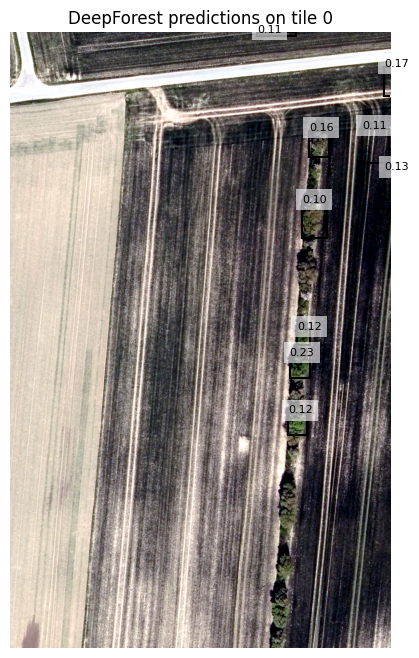

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

idx = 0

rgb_u8 = load_rgb_for_deepforest(TEST_DIR, idx)
predictions = all_predictions[idx]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_u8)
ax.set_title(f"DeepForest predictions on tile {idx}")
ax.axis("off")

if predictions is not None and len(predictions) > 0:
    for _, row in predictions.iterrows():
        xmin = row["xmin"]
        ymin = row["ymin"]
        xmax = row["xmax"]
        ymax = row["ymax"]
        score = row["score"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin,
            f"{score:.2f}",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

plt.show()

## Step 14: Save a qualitative baseline example

The prediction visualization is saved as an image file so it can be included in the project README or baseline report.

This qualitative example supports the numerical evaluation by showing how the zero-shot DeepForest detector behaves on the Denmark test data. It helps communicate why the baseline performance is limited and why a domain-specific model is needed in the next project phase.

# Step 14: Save one qualitative prediction visualization


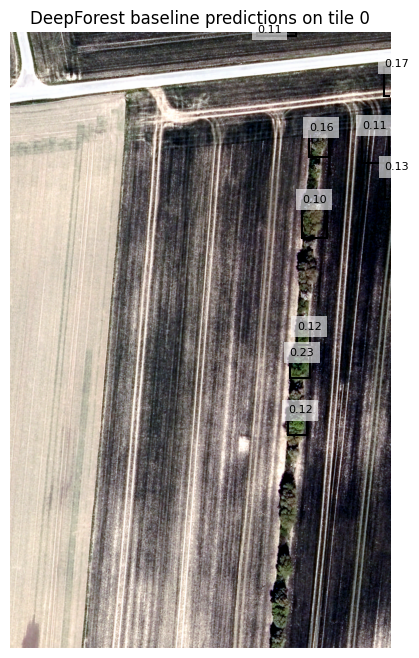

Saved visualization to:
/content/baseline_outputs/deepforest_predictions_tile_0.png


In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

output_dir = Path("/content/baseline_outputs")
output_dir.mkdir(exist_ok=True)

idx = 0

rgb_u8 = load_rgb_for_deepforest(TEST_DIR, idx)
predictions = all_predictions[idx]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_u8)
ax.set_title(f"DeepForest baseline predictions on tile {idx}")
ax.axis("off")

if predictions is not None and len(predictions) > 0:
    for _, row in predictions.iterrows():
        xmin = row["xmin"]
        ymin = row["ymin"]
        xmax = row["xmax"]
        ymax = row["ymax"]
        score = row["score"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=1.5
        )
        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin,
            f"{score:.2f}",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

image_path = output_dir / f"deepforest_predictions_tile_{idx}.png"

plt.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved visualization to:")
print(image_path)

## Step 15: Baseline model summary

This baseline uses DeepForest, a pretrained RetinaNet-based tree crown detector, as a zero-shot model on the Denmark test dataset. The model is not trained or fine-tuned on the Denmark data. It is applied directly to the test tiles using only the RGB bands.

The baseline produced `1190` predicted tree crown boxes across `25` test tiles. These predictions were converted into circles and compared against `2647` valid ground-truth tree crown circles using a circle-IoU threshold of `0.5`.

The final baseline performance was:

- Precision: `0.0286`
- Recall: `0.0128`
- F1-score: `0.0177`
- True positives: `34`
- False positives: `1156`
- False negatives: `2613`
- Mean matched IoU: `0.3102`

The low precision and recall show that the zero-shot DeepForest model transfers poorly to the Denmark dataset under this evaluation setup. This is expected because DeepForest was trained on a different domain and uses only RGB information, while the Denmark dataset also contains infrared, NDVI, and CHM channels.

This result is useful because it provides a lower-bound reference. The next model should improve over this baseline by using domain-specific training and the richer available input features.

# Step 15: Save baseline summary text

In [44]:

summary_text = f"""
Baseline Model Summary

Model:
DeepForest pretrained tree crown detector.

Baseline setting:
Zero-shot inference on Denmark test data.
No fine-tuning was performed.
Only RGB bands were used.

Dataset:
Number of test tiles: {len(indices)}
Total predicted circles: {sum(len(v) for v in pred_circles.values())}
Total ground-truth circles: {sum(len(v) for v in gt_circles.values())}

Performance:
Precision: {overall_precision:.4f}
Recall: {overall_recall:.4f}
F1-score: {overall_f1:.4f}
True positives: {overall_tp}
False positives: {overall_fp}
False negatives: {overall_fn}
Mean matched IoU: {df_results["mean_iou"].mean():.4f}

Interpretation:
The baseline performance is low, which indicates that the pretrained RGB-only DeepForest model does not transfer well to the Denmark test set without fine-tuning. This establishes a useful lower-bound reference for later models that can use domain-specific training and additional channels such as infrared, NDVI, and CHM.
"""

summary_path = output_dir / "deepforest_baseline_summary.txt"

with open(summary_path, "w") as f:
    f.write(summary_text)

print("Saved baseline summary to:")
print(summary_path)

print(summary_text)

Saved baseline summary to:
/content/baseline_outputs/deepforest_baseline_summary.txt

Baseline Model Summary

Model:
DeepForest pretrained tree crown detector.

Baseline setting:
Zero-shot inference on Denmark test data.
No fine-tuning was performed.
Only RGB bands were used.

Dataset:
Number of test tiles: 25
Total predicted circles: 1190
Total ground-truth circles: 2647

Performance:
Precision: 0.0286
Recall: 0.0128
F1-score: 0.0177
True positives: 34
False positives: 1156
False negatives: 2613
Mean matched IoU: 0.3102

Interpretation:
The baseline performance is low, which indicates that the pretrained RGB-only DeepForest model does not transfer well to the Denmark test set without fine-tuning. This establishes a useful lower-bound reference for later models that can use domain-specific training and additional channels such as infrared, NDVI, and CHM.

